# ESA Project1 Section6


In [6]:
from google.colab import files

uploaded = files.upload()


Saving Companion Excel File.xlsx to Companion Excel File (2).xlsx


Maximum Network Load (Pmax): 80.70 MW
Required Capacity for Gas (CC): 80.70 MW
Required Capacity for Coal: 80.70 MW
Required Capacity for Nuclear: 80.70 MW
Required Capacity for Solar: 372.46 MW
Required Capacity for Wind: 147.73 MW
Running simulations... (This might take a moment)

Sample of Results (First 5 rows):
  Technology  Interest Rate (%)  Load Growth (%)  Price Growth (%)  \
0   Gas (CC)                  3                0                 1   
1   Gas (CC)                  3                0                 2   
2   Gas (CC)                  3                0                 2   
3   Gas (CC)                  3                0                 2   
4   Gas (CC)                  3                0                 3   

   Avg Annual Profit ($)  Total 20Y Profit ($)  
0             34,819,531           696,390,620  
1             37,895,781           757,915,621  
2             41,165,511           823,310,212  
3             44,641,505           892,830,094  
4             48

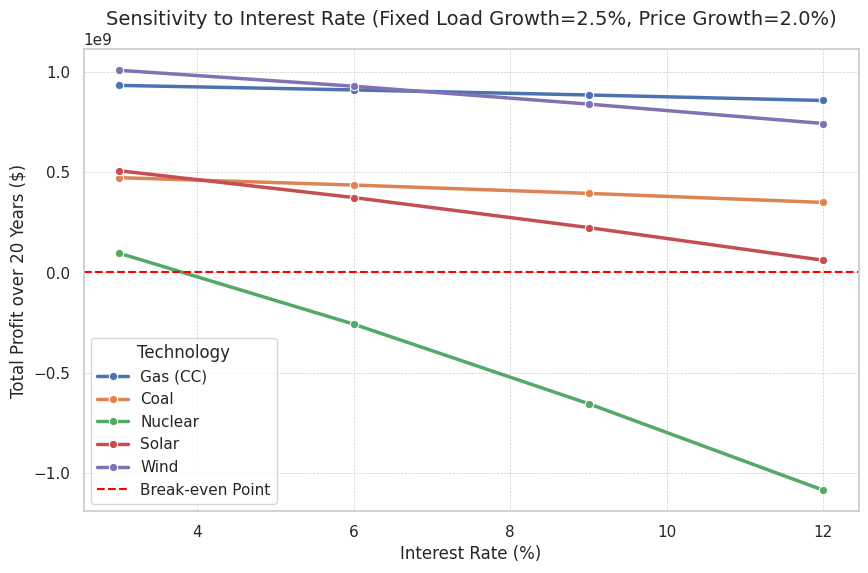

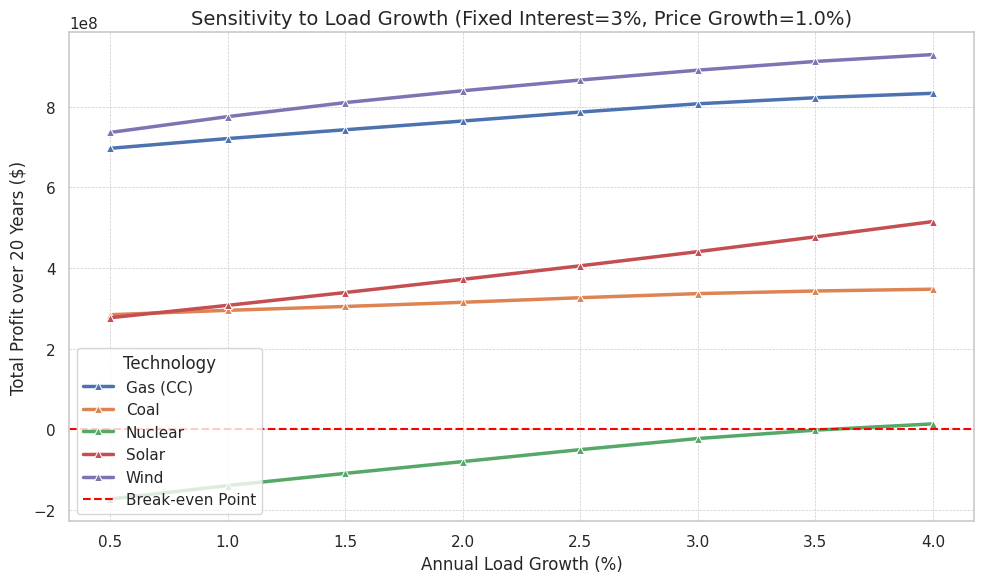

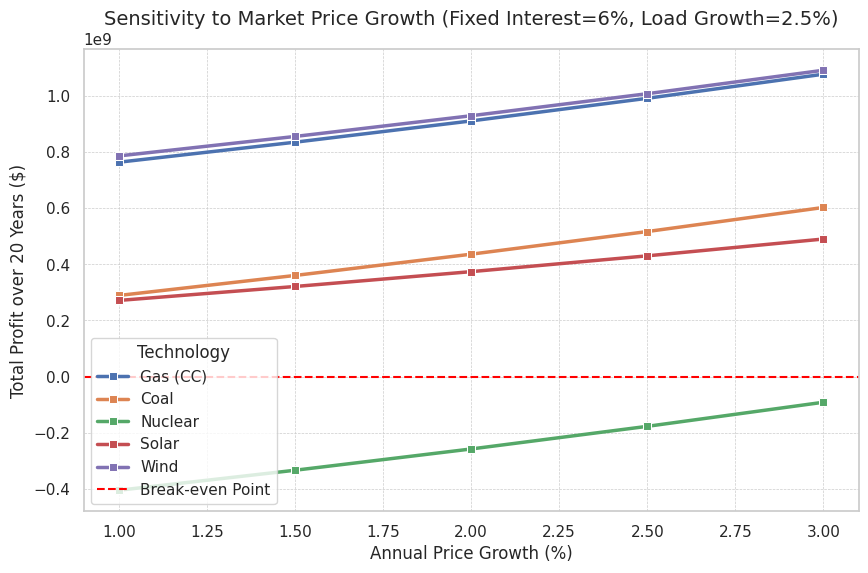

/tmp/ipython-input-1823415685.py:370: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_results, x="Technology", y="Total 20Y Profit ($)", palette="Set3")


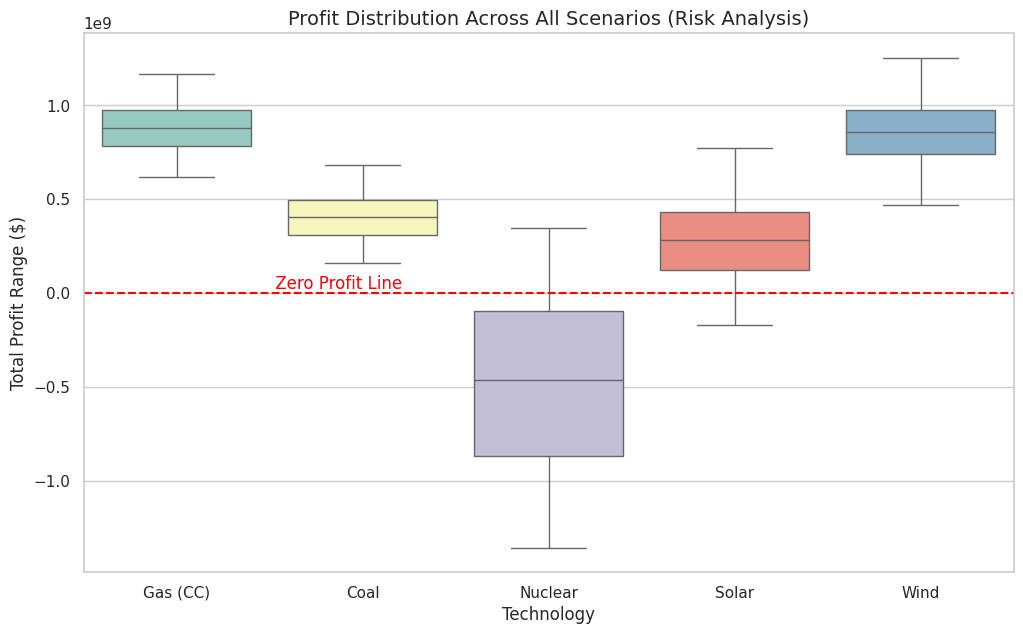

In [16]:
import numpy as np
import pandas as pd
import itertools


load_peak_profile = np.array([
    63.1, 62.5, 62.1, 61.9, 62.0, 66.2, 70.8, 72.0, 73.4, 74.6, 75.8, 77.2,
    78.6, 79.8, 80.7, 79.2, 77.9, 76.1, 74.3, 72.1, 69.8, 67.4, 65.2, 63.9
])

load_normal_profile = np.array([
    41.9, 41.7, 41.9, 42.2, 42.8, 44.1, 46.5, 46.9, 47.2, 47.9, 48.6, 49.4,
    49.9, 50.3, 50.8, 50.1, 49.3, 48.7, 48.2, 47.6, 46.8, 45.9, 44.8, 43.9
])

market_price_profile = np.array([
    4.3, 4.1, 4.2, 4.4, 4.7, 5.5, 6.8, 7.5, 8.1, 9.0, 10.4, 11.6,
    12.2, 13.0, 14.6, 16.8, 19.5, 21.0, 18.6, 16.4, 12.1, 7.2, 5.6, 4.9
])

wind_profile_per_kw = np.array([
    0.57, 0.53, 0.50, 0.48, 0.46, 0.68, 0.70, 0.66, 0.60, 0.56, 0.54, 0.53,
    0.52, 0.48, 0.44, 0.42, 0.40, 0.59, 0.62, 0.60, 0.58, 0.56, 0.55, 0.54
])

solar_profile_per_kw = np.array([
    0, 0, 0, 0, 0, 0.03, 0.10, 0.22, 0.38, 0.52, 0.60, 0.66,
    0.64, 0.61, 0.54, 0.42, 0.28, 0.14, 0.06, 0, 0, 0, 0, 0
])


carbon_tax = 25 # $/ton

technologies = {
    "Gas (CC)": {
        "CAPEX": 700 * 1000,   # $/MW
        "OPEX": 3.2 * 10,      # $/MWh
        "CO2": 380 * 0.001,    # ton/MWh
        "Type": "Thermal"
    },
    "Coal": {
        "CAPEX": 1150 * 1000,
        "OPEX": 5.4 * 10,
        "CO2": 880 * 0.001,
        "Type": "Thermal"
    },
    "Nuclear": {
        "CAPEX": 11000 * 1000,
        "OPEX": 1.8 * 10,
        "CO2": 0,
        "Type": "Thermal"
    },
    "Solar": {
        "CAPEX": 900 * 1000,
        "OPEX": 1.1 * 10,
        "CO2": 0,
        "Type": "Renewable",
        "Profile": solar_profile_per_kw
    },
    "Wind": {
        "CAPEX": 1350 * 1000,
        "OPEX": 1.6 * 10,
        "CO2": 0,
        "Type": "Renewable",
        "Profile": wind_profile_per_kw
    }
}



days_normal = 200
days_peak = 165
hours_per_year = 8760


annual_load = np.concatenate([np.tile(load_normal_profile, days_normal), np.tile(load_peak_profile, days_peak)])
annual_price_cents = np.concatenate([np.tile(market_price_profile, days_normal + days_peak)])
annual_price_dollar_mwh = annual_price_cents * 10 # تبدیل سنت/کیلووات‌ساعت به دلار/مگاوات‌ساعت

P_max = np.max(annual_load)
print(f"Maximum Network Load (Pmax): {P_max:.2f} MW")


def calculate_required_capacity(tech_name, tech_data, P_max, annual_load):
    """
    ظرفیت مورد نیاز را بر اساس استراتژی ذکر شده در پروژه محاسبه می‌کند.
    برای حرارتی: برابر با پیک بار.
    برای تجدیدپذیر: بر اساس ضریب ظرفیت (CF) محاسبه شده از پروفیل‌ها.
    """
    if tech_data["Type"] == "Thermal":
        return P_max
    else:

        profile_24h = tech_data["Profile"]
        annual_profile = np.tile(profile_24h, days_normal + days_peak)
        cf = np.mean(annual_profile)


        return P_max / cf

installed_capacities = {}
for name, data in technologies.items():
    cap = calculate_required_capacity(name, data, P_max, annual_load)
    installed_capacities[name] = cap
    print(f"Required Capacity for {name}: {cap:.2f} MW")


def calculate_scenario_profit(tech_name, interest_rate, load_growth, price_growth, horizon=20):

    tech = technologies[tech_name]
    capacity = installed_capacities[tech_name]


    i = interest_rate / 100.0
    n = horizon
    if i == 0:
        crf = 1/n
    else:
        crf = (i * (1 + i)**n) / ((1 + i)**n - 1)

    annual_capex = tech["CAPEX"] * capacity * crf

    profits = []

    current_annual_load = annual_load.copy()
    current_price_profile = annual_price_dollar_mwh.copy()

    if tech["Type"] == "Renewable":
        base_generation_profile = np.tile(tech["Profile"], days_normal + days_peak)

    for year in range(1, horizon + 1):

        if year > 1:
            current_annual_load = current_annual_load * (1 + load_growth/100.0)
            current_price_profile = current_price_profile * (1 + price_growth/100.0)

        if tech["Type"] == "Thermal":

            generation = np.minimum(current_annual_load, capacity)
        else:

            potential_generation = base_generation_profile * capacity


            generation = np.minimum(potential_generation, current_annual_load)

        total_energy_mwh = np.sum(generation)


        revenue = np.sum(generation * current_price_profile)


        variable_cost_per_mwh = tech["OPEX"] + (tech["CO2"] * carbon_tax)
        total_variable_cost = total_energy_mwh * variable_cost_per_mwh


        annual_profit = revenue - (annual_capex + total_variable_cost)

        profits.append(annual_profit)

    return profits


r_range = np.arange(3, 13, 3)
load_g_range = np.arange(0.5, 4.5, 0.5)
price_g_range = np.arange(1, 3.5, 0.5)
results = []

print("Running simulations... (This might take a moment)")

for tech in technologies.keys():
    for r in r_range:
        for lg in load_g_range:
            for pg in price_g_range:
                yearly_profits = calculate_scenario_profit(tech, r, lg, pg)

                avg_profit = np.mean(yearly_profits)
                total_profit_npv = np.sum(yearly_profits)

                results.append({
                    "Technology": tech,
                    "Interest Rate (%)": r,
                    "Load Growth (%)": lg,
                    "Price Growth (%)": pg,
                    "Avg Annual Profit ($)": avg_profit,
                    "Total 20Y Profit ($)": total_profit_npv
                })

df_results = pd.DataFrame(results)

pd.set_option('display.float_format', '{:,.0f}'.format)
print("\nSample of Results (First 5 rows):")
print(df_results.head())


print("\n--- Summary Analysis ---")
summary = df_results.groupby("Technology")["Total 20Y Profit ($)"].mean().sort_values(ascending=False)
print("Ranking Technologies by Average Profit across ALL scenarios:")
print(summary)


gas_low_r = df_results[(df_results["Technology"]=="Gas (CC)") & (df_results["Interest Rate (%)"]==3)]["Total 20Y Profit ($)"].mean()
gas_high_r = df_results[(df_results["Technology"]=="Gas (CC)") & (df_results["Interest Rate (%)"]==12)]["Total 20Y Profit ($)"].mean()
print(f"\nImpact of Interest Rate on Gas Plant Profit:")
print(f"At 3% Interest: ${gas_low_r:,.0f}")
print(f"At 12% Interest: ${gas_high_r:,.0f}")

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'


median_load_growth = 2.5
median_price_growth = 2.0

df_interest = df_results[
    (df_results["Load Growth (%)"] == median_load_growth) &
    (df_results["Price Growth (%)"] == median_price_growth)
]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_interest, x="Interest Rate (%)", y="Total 20Y Profit ($)", hue="Technology", marker="o", linewidth=2.5)

plt.title(f"Sensitivity to Interest Rate (Fixed Load Growth={median_load_growth}%, Price Growth={median_price_growth}%)", fontsize=14)
plt.xlabel("Interest Rate (%)", fontsize=12)
plt.ylabel("Total Profit over 20 Years ($)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', label="Break-even Point")
plt.legend(title="Technology")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()


fixed_interest_for_load = 3
fixed_price_growth_for_load = 1.0

df_load_growth = df_results[
    (df_results["Interest Rate (%)"] == fixed_interest_for_load) &
    (df_results["Price Growth (%)"] == fixed_price_growth_for_load)
]

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df_load_growth,
    x="Load Growth (%)",
    y="Total 20Y Profit ($)",
    hue="Technology",
    marker="^",
    linewidth=2.5
)

plt.title(f"Sensitivity to Load Growth (Fixed Interest={fixed_interest_for_load}%, Price Growth={fixed_price_growth_for_load}%)", fontsize=14)
plt.xlabel("Annual Load Growth (%)", fontsize=12)
plt.ylabel("Total Profit over 20 Years ($)", fontsize=12)

plt.axhline(0, color='red', linestyle='--', label="Break-even Point")

plt.legend(title="Technology")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()



fixed_interest = 6
fixed_load_growth = 2.5

df_price = df_results[
    (df_results["Interest Rate (%)"] == fixed_interest) &
    (df_results["Load Growth (%)"] == fixed_load_growth)
]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_price, x="Price Growth (%)", y="Total 20Y Profit ($)", hue="Technology", marker="s", linewidth=2.5)

plt.title(f"Sensitivity to Market Price Growth (Fixed Interest={fixed_interest}%, Load Growth={fixed_load_growth}%)", fontsize=14)
plt.xlabel("Annual Price Growth (%)", fontsize=12)
plt.ylabel("Total Profit over 20 Years ($)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', label="Break-even Point")
plt.legend(title="Technology")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_results, x="Technology", y="Total 20Y Profit ($)", palette="Set3")

plt.title("Profit Distribution Across All Scenarios (Risk Analysis)", fontsize=14)
plt.xlabel("Technology", fontsize=12)
plt.ylabel("Total Profit Range ($)", fontsize=12)
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.text(0.5, 0, ' Zero Profit Line', color='red', va='bottom', ha='left')

plt.show()